# Ito (2024) RF full-depth sampling maps

Alternate notebook producer for `Figures/GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf`. Includes its trend and volume-weighting helpers so it runs independently.


In [ ]:
from pathlib import Path
import string
import textwrap
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

import netCDF4 as nc

FULL = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/NETCDF/Fully_sampled_models_annual_o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc')

def edges(z):
    z = np.asarray(z, float); e = np.empty(z.size + 1)
    e[1:-1] = (z[:-1] + z[1:]) / 2; e[0] = max(0, z[0] - (z[1]-z[0])/2); e[-1] = z[-1] + (z[-1]-z[-2])/2
    return e

def years(ds):
    t = ds.variables['time']; return np.array([d.year for d in nc.num2date(t[:], t.units, calendar=getattr(t, 'calendar', 'standard'))])

def trend(path, start=1967, end=2019):
    with nc.Dataset(path) as ds:
        zname = 'lev' if 'lev' in ds.variables else 'depth'; yname = 'y' if 'y' in ds.variables else 'lat'; xname = 'x' if 'x' in ds.variables else 'lon'
        z, lat, lon = [np.asarray(ds.variables[n][:], float) for n in (zname, yname, xname)]; lon = np.mod(lon, 360)
        v = ds.variables['o2']; ta = v.dimensions.index('time'); rem = [d for d in v.dimensions if d != 'time']; order = [rem.index(n) for n in (zname, yname, xname)]
        shape = (z.size, lat.size, lon.size); yy = years(ds)
        wanted_indices = np.array([np.flatnonzero(yy == year)[0] for year in range(start, end + 1)])
        # The objective-mapping products store time last. Reading one longitude
        # slab at a time is orders of magnitude faster than 53 strided global reads.
        if v.dimensions == (xname, yname, zname, 'time'):
            out = np.full(shape, np.nan)
            xyears = np.arange(start, end + 1, dtype=float); xc = xyears - xyears.mean(); denom = np.sum(xc * xc)
            for i in range(0, lon.size, 90):
                j = min(i + 90, lon.size)
                a = np.ma.filled(v[i:j, :, :, wanted_indices], np.nan).astype(float)
                a[a > 1e19] = np.nan
                a = np.transpose(a, (2, 1, 0, 3))
                ok = np.isfinite(a).all(axis=3)
                slope = np.sum(a * xc[None, None, None, :], axis=3) / denom * 10
                out[:, :, i:j] = np.where(ok, slope, np.nan)
                print(f'  {path.name}: longitudes {i + 1}-{j}', flush=True)
            return z, lat, lon, out
        n = np.zeros(shape); sx = np.zeros(shape); sy = np.zeros(shape); sxx = np.zeros(shape); sxy = np.zeros(shape)
        for year in range(start, end + 1):
            total = np.zeros(shape); count = np.zeros(shape, dtype=np.uint8)
            for ti in np.flatnonzero(yy == year):
                ind = [slice(None)] * v.ndim; ind[ta] = int(ti); a = np.ma.filled(v[tuple(ind)], np.nan).astype(float); a[a > 1e19] = np.nan; a = np.transpose(a, order); ok = np.isfinite(a); total += np.where(ok, a, 0); count += ok
            a = np.divide(total, count, out=np.full(shape, np.nan), where=count > 0); ok = np.isfinite(a); n += ok; sx += np.where(ok, year, 0); sy += np.where(ok, a, 0); sxx += np.where(ok, year*year, 0); sxy += np.where(ok, year*a, 0)
    den = n*sxx - sx*sx
    return z, lat, lon, np.divide(n*sxy-sx*sy, den, out=np.full(shape, np.nan), where=(n == end-start+1) & (den != 0))*10

def volume_mean(a, z):
    dz = np.diff(edges(z))[:, None, None]; ok = np.isfinite(a); num = np.nansum(np.where(ok, a*dz, np.nan), axis=0); den = np.sum(np.where(ok, dz, 0), axis=0)
    return np.divide(num, den, out=np.full(num.shape, np.nan), where=den > 0)

def band_volumes():
    with nc.Dataset(FULL) as ds:
        z = np.asarray(ds.variables['lev'][:], float); v = ds.variables['o2']; a = np.ma.filled(v[0], np.nan)
    e = edges(z); dz1 = np.maximum(np.minimum(e[1:], 2000)-e[:-1], 0); dz2 = np.maximum(e[1:]-np.maximum(e[:-1], 2000), 0); ok = np.isfinite(a)
    return np.sum(np.where(ok, dz1[:,None,None], 0), axis=0), np.sum(np.where(ok, dz2[:,None,None], 0), axis=0)

def from_bands(ds, prefix, upper_v, lower_v):
    a=np.asarray(ds[f'{prefix}_upper_2000m'],float); b=np.asarray(ds[f'{prefix}_below_2000m'],float); oka=np.isfinite(a)&(upper_v>0); okb=np.isfinite(b)&(lower_v>0); num=np.where(oka,a*upper_v,0)+np.where(okb,b*lower_v,0); den=np.where(oka,upper_v,0)+np.where(okb,lower_v,0)
    return np.divide(num,den,out=np.full(num.shape,np.nan),where=den>0)

WORK = Path('/scratch/gpfs/LRGROUP/db9274/GFDL_ESM4_artificial_subsampling')
RF_DIR = WORK / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_RF'
MAP_DIR = WORK / 'trend_comparison_outputs/fully_minus_gap_filled_trend_maps'
ORIGINAL_MAP = MAP_DIR / 'ito2024_rf_original_4x_4xeast_8x.nc'
RANDOM_MAP = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/cache_gfdl_esm4_randobs_trend_error_maps.nc')
PCT30_MAP = MAP_DIR / 'fully_minus_gap_filled_rf_pct30_level_first_volume_weighted_1965_2021.nc'
OUT = Path('Figures/GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf')

def main():
    z, lat, lon, full = trend(FULL, 1965, 2021)
    upper_v, lower_v = band_volumes()
    with (
        xr.open_dataset(ORIGINAL_MAP) as original,
        xr.open_dataset(RANDOM_MAP) as random,
        xr.open_dataset(PCT30_MAP) as pct30,
    ):
        fields = [
            -from_bands(original, 'fully_minus_gap_filled_original', upper_v, lower_v),
            -from_bands(random, 'randobs_rf', upper_v, lower_v),
            -from_bands(pct30, 'fully_minus_gap_filled_rf30', upper_v, lower_v),
        ]

    cases = [
        'regional_tropical_2000',
        'regional_extratropical_2000', 'regional_southern_ocean_2000',
    ]
    for case in cases:
        path = RF_DIR / f'GFDL_ESM4_{case}_r1i1p1f1_oxygen_gridded_RF.nc'
        zz, yy, xx, mapped = trend(path, 1965, 2021)
        if not (np.allclose(z, zz) and np.allclose(lat, yy) and np.allclose(lon, xx)):
            raise ValueError(f'Coordinate mismatch: {path}')
        fields.append(volume_mean(mapped, zz) - volume_mean(full, z))
        print(f'Completed {case}', flush=True)

    labels = [
        'Historical\ncoverage',
        'Uniform sampling at\nhistorical coverage',
        'Uniform sampling at\n30% coverage',
        '2,000 added profiles:\nTropical Oceans',
        '2,000 added profiles:\nNorth Atlantic +\nNorth Pacific Oceans',
        '2,000 added profiles:\nSouthern Ocean',
    ]
    available = [f for f in fields if f is not None]
    values = np.concatenate([np.abs(f[np.isfinite(f)]) for f in available])
    limit = float(np.nanpercentile(values, 99))
    norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    plt.rcParams.update({'font.size': 11, 'pdf.fonttype': 42, 'savefig.dpi': 600, 'savefig.facecolor': 'white'})
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.0), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, constrained_layout=True)
    mesh = None
    for i, (ax, field, label) in enumerate(zip(axes.flat, fields, labels)):
        if field is not None:
            cyclic, cyclic_lon = add_cyclic_point(field, coord=lon)
            mesh = ax.pcolormesh(cyclic_lon, lat, cyclic, transform=ccrs.PlateCarree(), cmap='bwr', norm=norm, shading='auto', rasterized=True)
        ax.set_global(); ax.add_feature(cfeature.LAND, facecolor='0.85', edgecolor='none', zorder=2); ax.coastlines(linewidth=.45, color='.15', zorder=3); ax.gridlines(linewidth=.25, color='.55', alpha=.4)
        ax.set_title(f'{string.ascii_lowercase[i]}. {label}', fontsize=12, fontweight='bold', pad=7)
        if field is None:
            ax.text(.5, .5, 'Global RF output\nnot available', transform=ax.transAxes, ha='center', va='center', fontsize=11, color='.25')
    cb = fig.colorbar(mesh, ax=axes, orientation='horizontal', shrink=.62, pad=.08, aspect=35, extend='both'); cb.set_label('Sampling-mapping effect (µmol kg⁻¹ decade⁻¹)', fontsize=11); cb.ax.tick_params(labelsize=11)
    OUT.parent.mkdir(exist_ok=True); fig.savefig(OUT, bbox_inches='tight', pad_inches=.03); print(f'Saved {OUT}', flush=True); plt.show(); plt.close(fig)


In [ ]:
main()


**GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf**

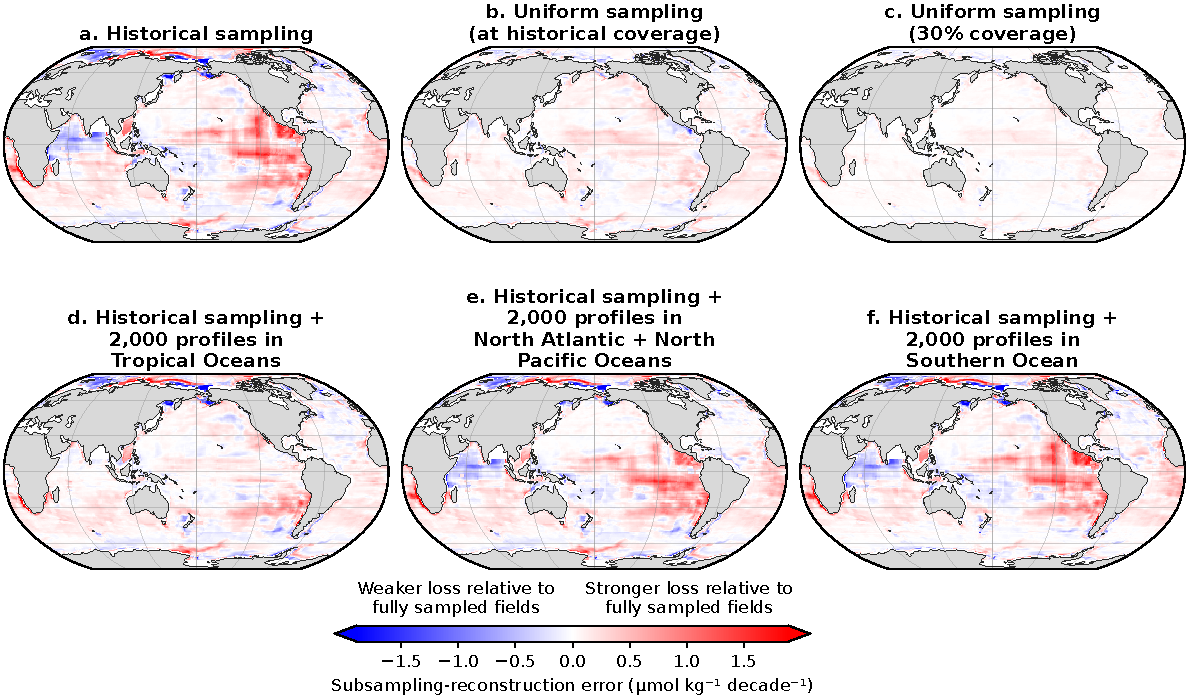

In [1]:
# Show the saved paper PDF in GitHub's notebook viewer.
from pathlib import Path
from tempfile import TemporaryDirectory
from IPython.display import Image, Markdown, display
import subprocess

PDF_PREVIEWS = tuple(Path(name) for name in ['Figures/GFDL_ESM4_Ito2024_RF_sampling_sensitivity_full_depth_maps.pdf'])

for pdf in PDF_PREVIEWS:
    display(Markdown(f"**{pdf.name}**"))
    with TemporaryDirectory() as temporary_dir:
        preview = Path(temporary_dir) / "preview.png"
        subprocess.run(["gs", "-q", "-dSAFER", "-dBATCH", "-dNOPAUSE",
                        "-sDEVICE=png16m", "-r125", "-dFirstPage=1", "-dLastPage=1",
                        f"-sOutputFile={preview}", str(pdf)], check=True)
        display(Image(filename=str(preview)))
